In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time

Text(0.5, 1.0, 'MSE Loss as a function of y_pred')

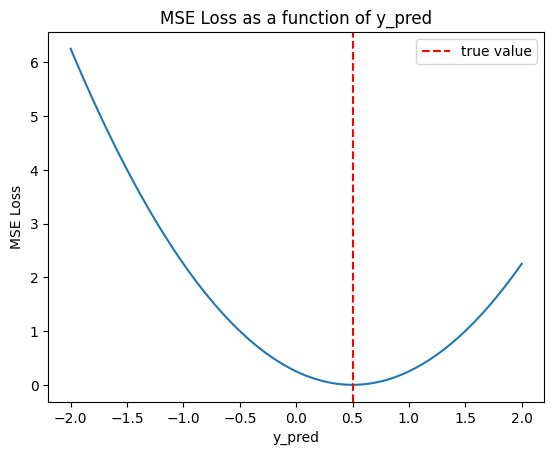

In [3]:
# loss function
loss_fn_mse = nn.MSELoss()

y_pred = torch.linspace(-2, 2, 101)
y = torch.tensor(.5)

# compute mse loss
L = np.zeros(len(y_pred))
for i in range(len(y_pred)):
    L[i] = loss_fn_mse(y_pred[i], y).item()

plt.plot(y_pred.numpy(), L)
plt.axvline(x=y.item(), color='r', linestyle='--', label='true value')
plt.legend()
plt.xlabel('y_pred')
plt.ylabel('MSE Loss')
plt.title('MSE Loss as a function of y_pred')

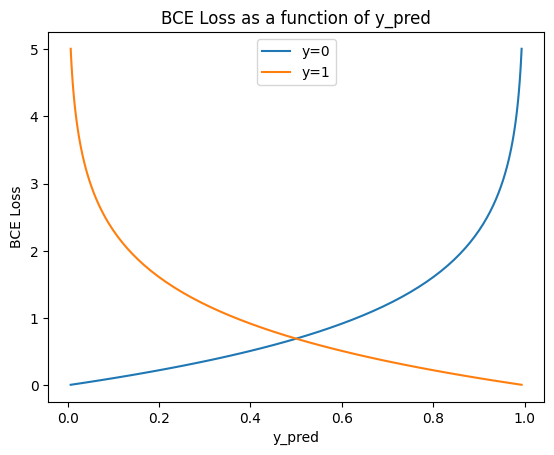

In [5]:
loss_fun_bce = nn.BCELoss()
y_pred_logits = torch.linspace(-5, 5, 101)
y_pred = torch.sigmoid(y_pred_logits) # we need to apply sigmoid to get probabilities between 0 and 1

y0 = torch.tensor(0.)
y1 = torch.tensor(1.)

L = np.zeros((len(y_pred), 2))

for i in range(len(y_pred)):
    L[i, 0] = loss_fun_bce(y_pred[i], y0).item()
    L[i, 1] = loss_fun_bce(y_pred[i], y1).item()

plt.plot(y_pred.numpy(), L[:, 0], label='y=0')
plt.plot(y_pred.numpy(), L[:, 1], label='y=1')
plt.xlabel('y_pred')
plt.ylabel('BCE Loss')
plt.title('BCE Loss as a function of y_pred')
plt.legend()
plt.show()

# here we see two loss functions, one for each class, and how they behave as a function 
# of the predicted probability. The loss is high when the predicted probability is far 
# from the true class and low when it is close to the true class. This illustrates how 
# the BCE loss penalizes incorrect predictions more heavily than correct ones, especially 
# as the predicted probability approaches 0 or 1.

In [ ]:
loss_fun_cce = nn.CrossEntropyLoss() # it will apply softmax internally.
# these are the raw logits (unnormalized scores) for each class, which can be any real numbers.
# output layer pre-softmax, so we can directly use these logits with CrossEntropyLoss, which
# applies the softmax function internally to convert them into probabilities.
y_pred_logits = torch.tensor([[1., 4., 3.]]) 
y_true = torch.tensor([0, 1, 2]) # these are the true class labels (0, 1, or 2)
for i in range(3):
    correct_class = y_true[i].item()
    L = loss_fun_cce(y_pred_logits, torch.tensor([correct_class])).item()
    print(f'Loss when correct answer is {i}: {L:.4f}')

# the smallest loss is when the class=1, since it has the highest logit (4), which 
# means the model is most confident about that class. The loss is higher for class 0,
# which had the smallest logit (1), so when the true class is 0, the error is higher.

Loss when correct answer is 0: 3.3490
Loss when correct answer is 1: 0.3490
Loss when correct answer is 2: 1.3490


In [22]:
# create your own custom loss of the form MSE
class CustomLoss(nn.Module):
    def __init__(self, alpha=1.0):
        super(CustomLoss, self).__init__()

    def forward(self, y_pred, y_true):
        mse_loss = F.mse_loss(y_pred, y_true)
        return mse_loss
    
# example usage
y_pred = torch.tensor([0.5, 2.0, 1.5])
y_true = torch.tensor([0.0, 1.0, 0.0])
alpha = 0.5
custom_loss_fn = CustomLoss(alpha=alpha)

mse_loss = F.mse_loss(y_pred, y_true)
custom_loss = custom_loss_fn(y_pred, y_true)

print(f'MSE Loss: {mse_loss.item():.4f}')
print(f'Custom Loss: {custom_loss.item():.4f}')

MSE Loss: 1.1667
Custom Loss: 1.1667
